In [ ]:
from joblib import load
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point

In [3]:
ct=gpd.read_file('Result.geojson')

In [4]:
print(ct.columns)

Index(['shape_area', 'ntaname', 'cdtaname', 'shape_leng', 'boroname', 'ct2020',
       'nta2020', 'borocode', 'cdeligibil', 'geoid', 'boroct2020', 'cdta2020',
       'ctlabel', 'area_hectare', 'population_2023', 'pop_density',
       'unemployment', 'unrelated individuals', 'citizen ratio',
       'less than high school', 'GINI index', 'per capita income',
       'gross rent', 'tree_count', 'good_tree_count', 'lotarea_sum',
       'landuse_count', 'comarea_sum', 'resarea_sum', 'assesstot_sum',
       'numfloor_sum', 'bldgarea_sum', 'ComFAR', 'ResFAR', 'assesstot',
       'NumFloors', 'Avr floor area', 'building_count', 'building_height_sum',
       'avr height', 'building density', 'tree density', 'good tree density',
       'unrelated individual', 'pop_change_forest', 'pop_change_forest_prob_1',
       'pop_change_type_forest', 'pop_change_type_forest_prob_2',
       'pop_change_type_forest_prob_0', 'geometry'],
      dtype='object')


## *Population Growth Classification*

In [5]:
import shap

In [6]:
forest1=load('predictive model/random_forest_growth.pkl')

In [7]:
features_selected = ['less than high school', 'pop_density', 'citizen ratio', 'unemployment',
        'unrelated individual', 'GINI index', 'gross rent', 'assesstot','ResFAR',
        'building density', 'tree density', 'good tree density','per capita income']

In [ ]:
X = ct[features_selected]

In [10]:
X500 = shap.utils.sample(X,500)
explainer_xgb = shap.Explainer(lambda x: forest1.predict_proba(x)[:, 1], X500)
shap_values_xgb = explainer_xgb(X)

PermutationExplainer explainer: 2326it [04:58,  7.67it/s]                          


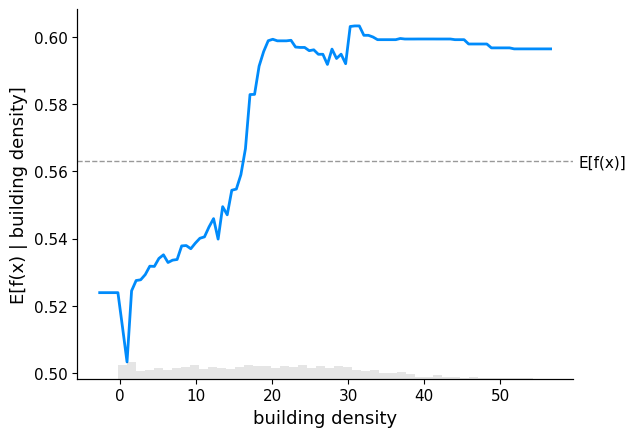

In [59]:
fig, ax = shap.partial_dependence_plot(
    "building density",
    lambda x: forest1.predict_proba(x)[:, 1],
    X,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ice=False,
)

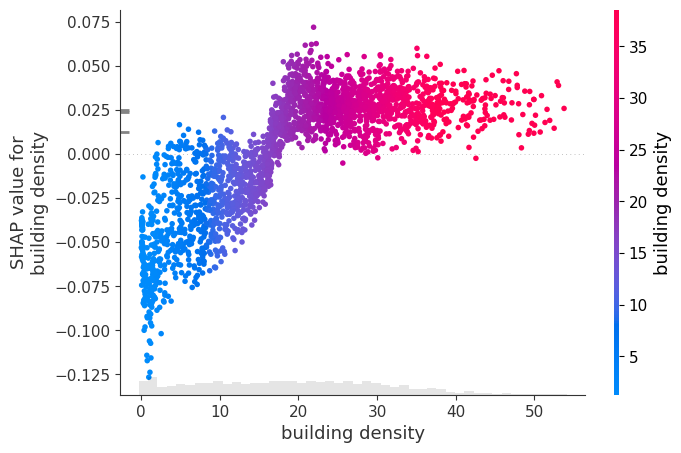

In [17]:
shap.plots.scatter(shap_values_xgb[:, "building density"], color=shap_values_xgb[:, "building density"])

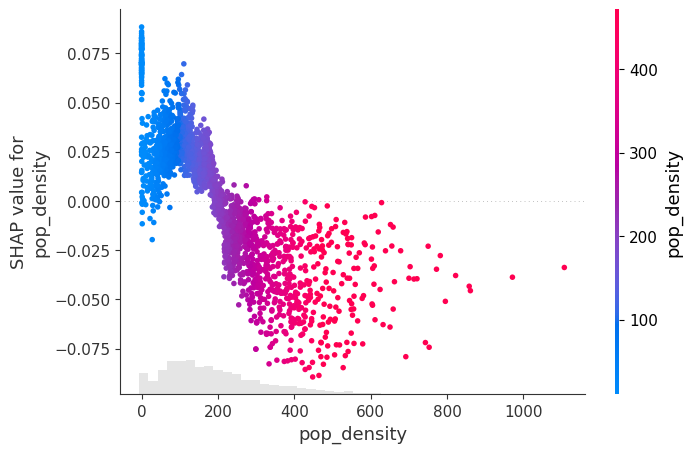

In [18]:
shap.plots.scatter(shap_values_xgb[:, "pop_density"], color=shap_values_xgb[:, "pop_density"])

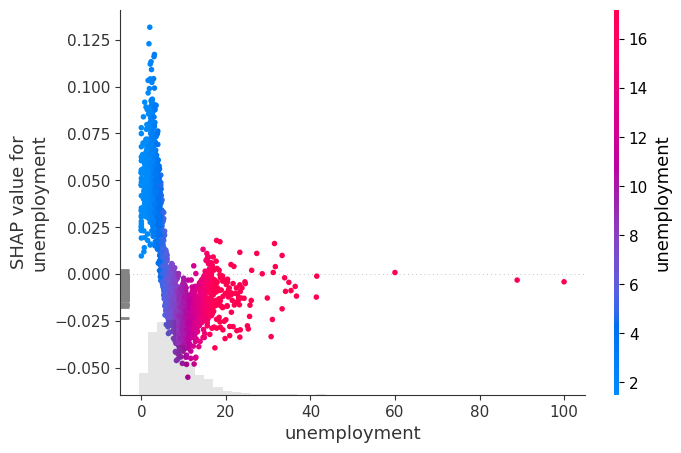

In [19]:
shap.plots.scatter(shap_values_xgb[:, "unemployment"], color=shap_values_xgb[:, "unemployment"])

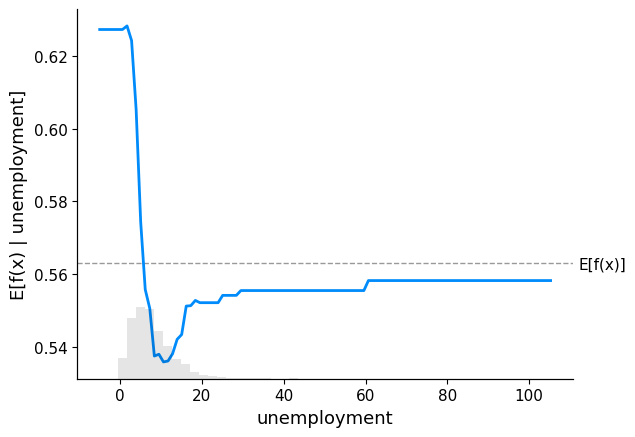

In [58]:
fig, ax = shap.partial_dependence_plot(
    "unemployment",
    lambda x: forest1.predict_proba(x)[:, 1],
    X,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ice=False,
)

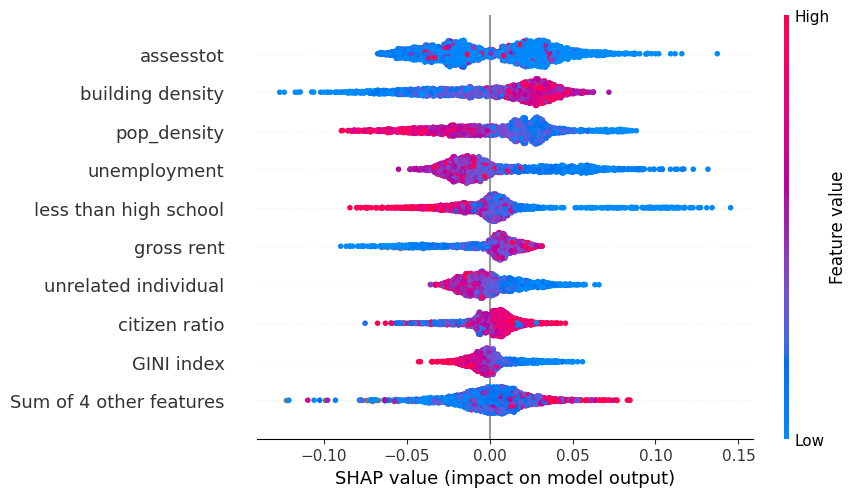

In [11]:
shap.plots.beeswarm(shap_values_xgb)

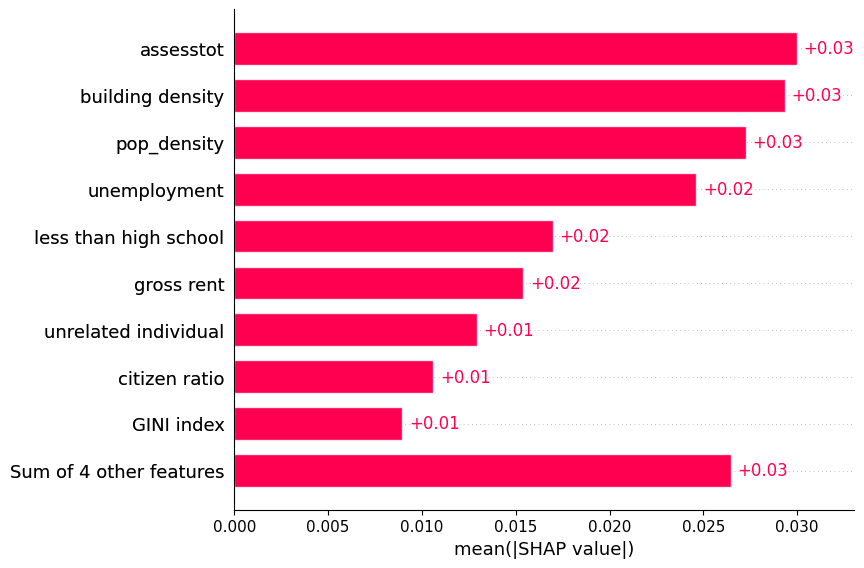

In [12]:
shap.plots.bar(shap_values_xgb)

In [13]:
clustering = shap.utils.hclust(X, y)

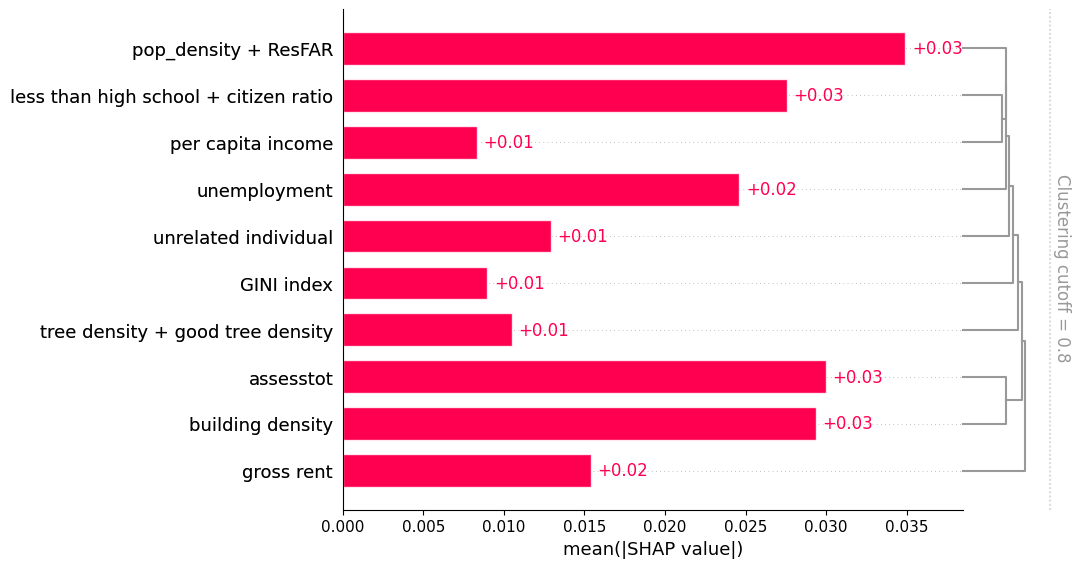

In [14]:
shap.plots.bar(shap_values_xgb, clustering=clustering, clustering_cutoff=0.8)

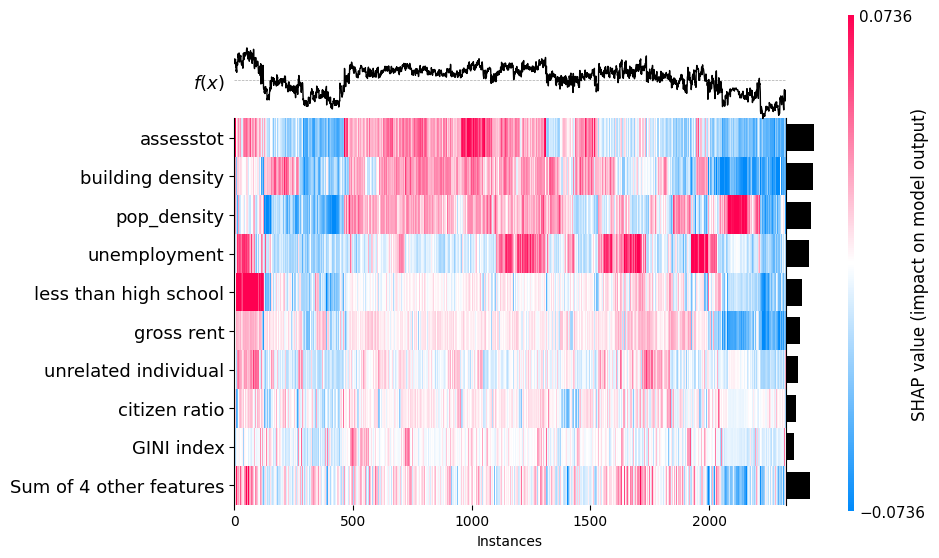

<Axes: xlabel='Instances'>

In [15]:
shap.plots.heatmap(shap_values_xgb)

In [86]:
probs = forest1.predict_proba(X)[:, 1]

In [93]:
max_index = np.argmax(probs)
min_index = np.argmin(probs)
median_prob = np.median(probs)
diff = np.abs(probs - median_prob)
median_index = np.argmin(diff)
print(max_index)
print(min_index)
print(median_index)

25
1045
2081


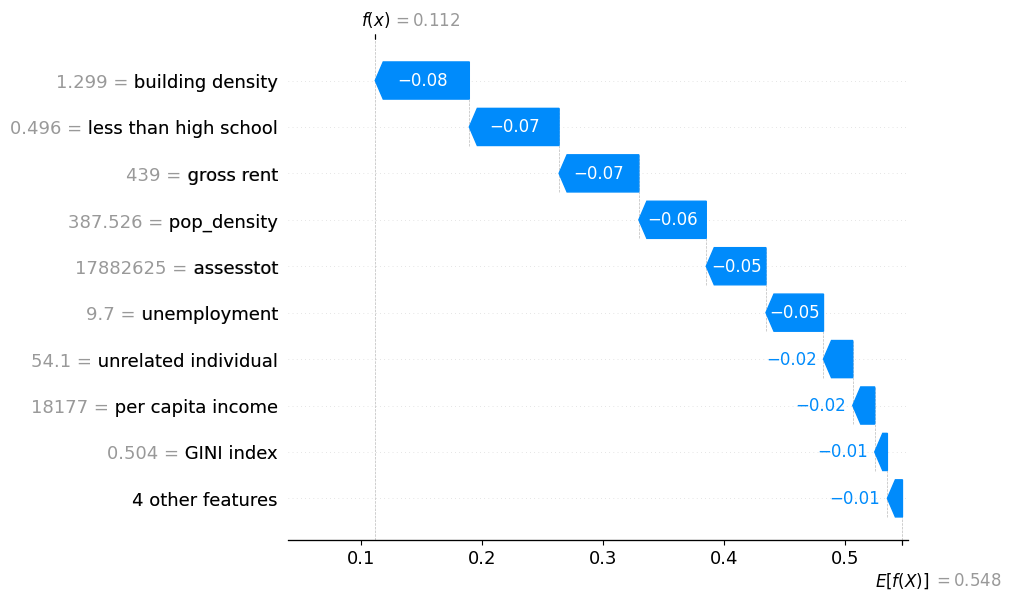

In [91]:
shap.plots.waterfall(shap_values_xgb[1045])

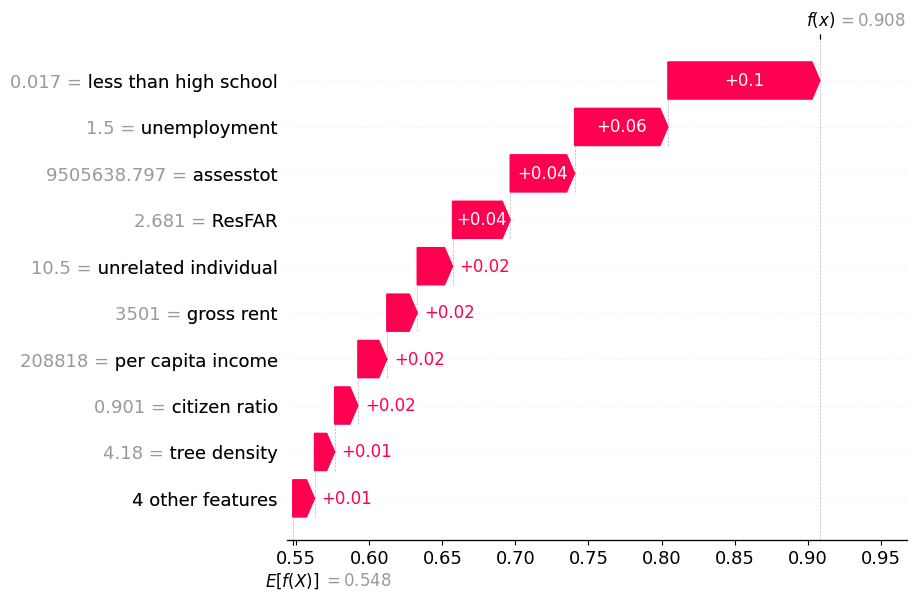

In [90]:
shap.plots.waterfall(shap_values_xgb[25])

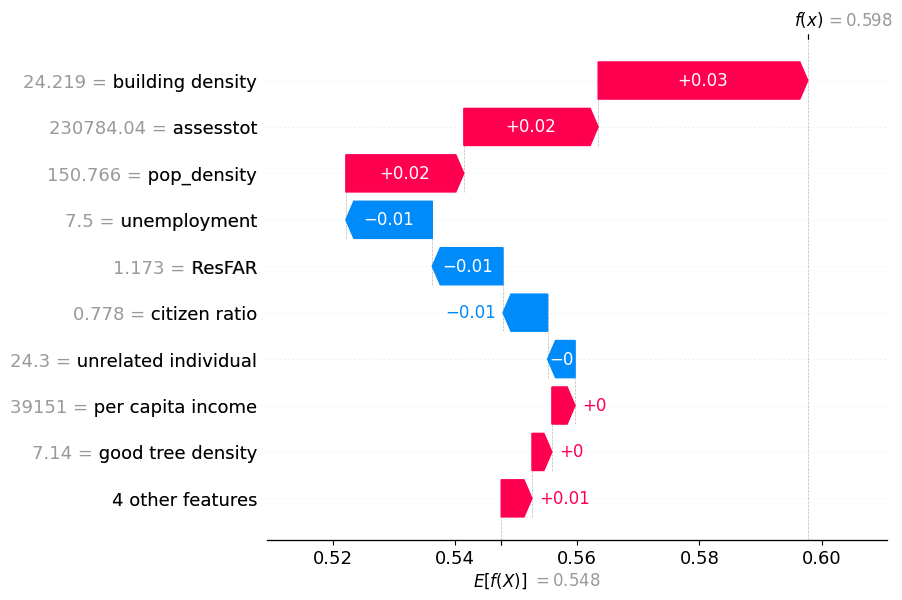

In [94]:
shap.plots.waterfall(shap_values_xgb[2081])

In [142]:
# sample_ind = 1000

In [143]:
# shap.plots.waterfall(shap_values_xgb[sample_ind])

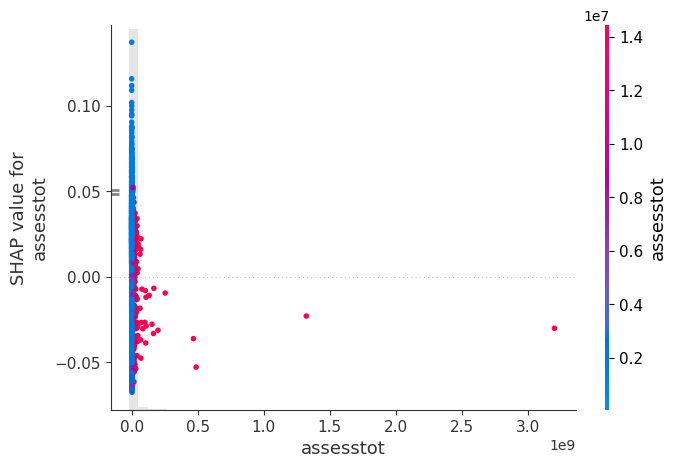

In [50]:
shap.plots.scatter(shap_values_xgb[:, "assesstot"], color=shap_values_xgb[:, "assesstot"])

In [66]:
X_filtered = X[X['assesstot'] < 1.5*1e6]

In [67]:
X400 = shap.utils.sample(X_filtered,400)
explainer_xgb_2 = shap.Explainer(lambda x: forest1.predict_proba(x)[:, 1], X400)
shap_values_xgb_2 = explainer_xgb_2(X_filtered)

PermutationExplainer explainer: 1847it [03:33,  8.25it/s]                          


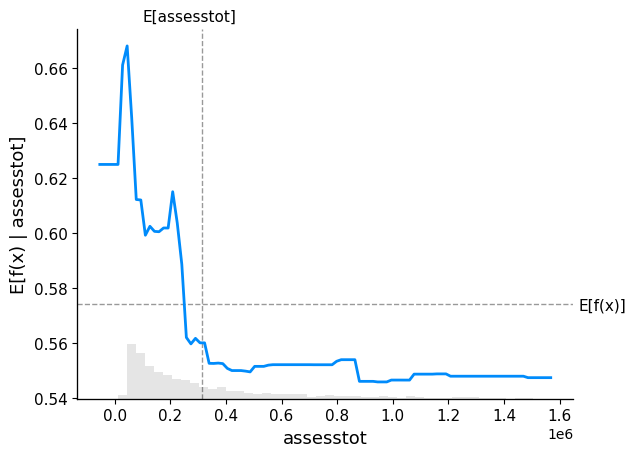

In [68]:
fig, ax = shap.partial_dependence_plot(
    "assesstot",
    lambda x: forest1.predict_proba(x)[:, 1],
    X_filtered,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ice=False,
)

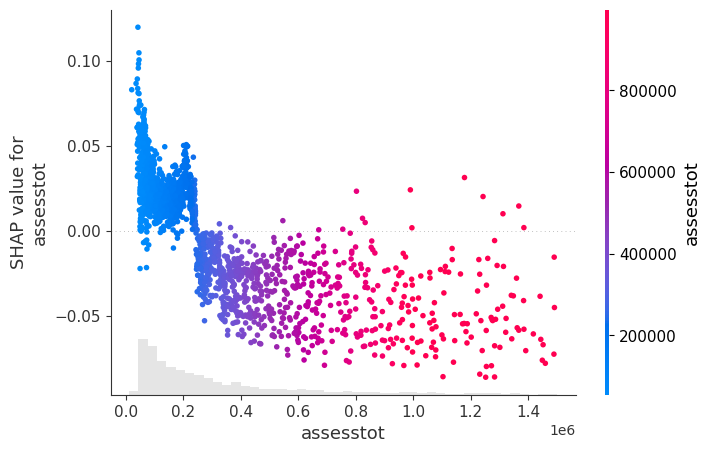

In [69]:
shap.plots.scatter(shap_values_xgb_2[:, "assesstot"], color=shap_values_xgb_2[:, "assesstot"])

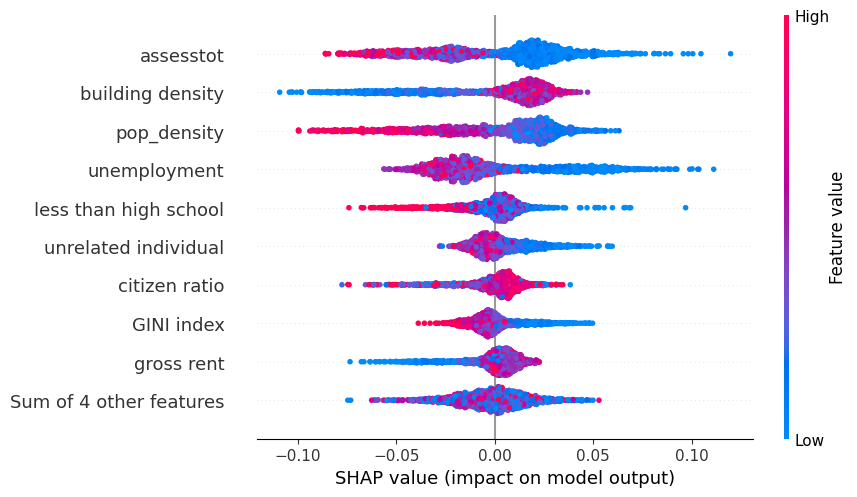

In [70]:
shap.plots.beeswarm(shap_values_xgb_2)

## *Classification of Population Growth Levels*

In [24]:
forest2=load("predictive model/forest_growth_type.pkl")

In [25]:
features_selected2 = ['less than high school', 'pop_density', 'citizen ratio', 'unemployment',
        'unrelated individual', 'GINI index', 'gross rent', 'assesstot','ComFAR',
        'building density', 'Avr floor area', 'good tree density','per capita income']

In [ ]:
X_type=ct[features_selected2]

In [27]:
X_500_2 = shap.utils.sample(X_type,500)
explainer_type = shap.Explainer(forest2, X_500_2)
shap_values_type = explainer_type(X_type)

100%|===================| 6962/6975 [01:20<00:00]        

##### Classification: 2

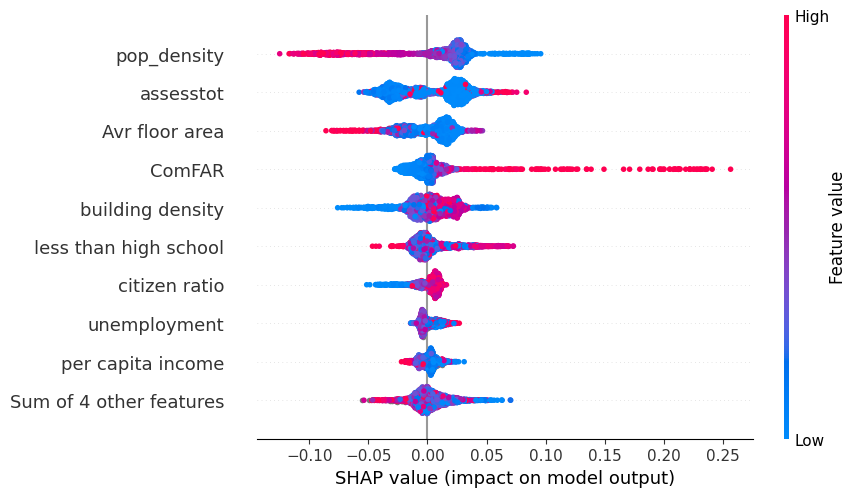

In [28]:
shap.plots.beeswarm(shap_values_type[..., 2])

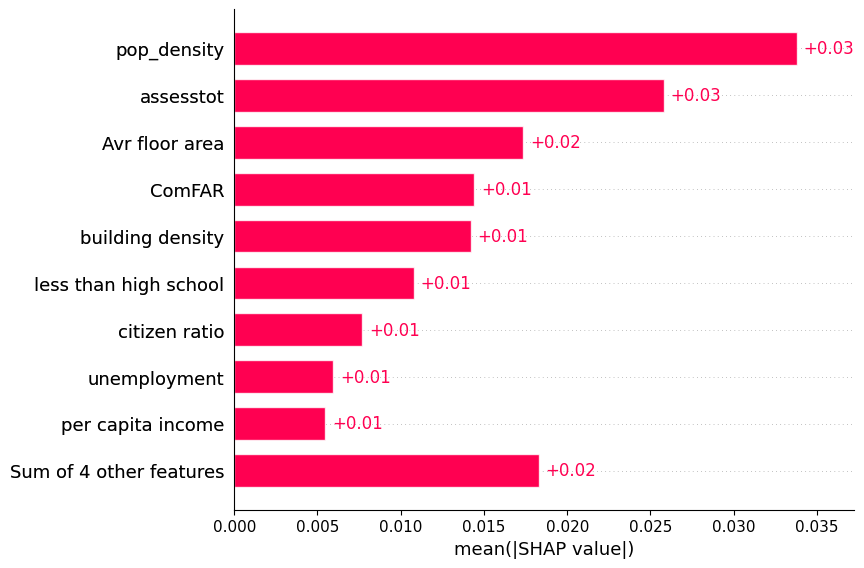

In [29]:
shap.plots.bar(shap_values_type[...,2])

In [40]:
y_type=ct['pop_change_type_forest_prob_2']

In [47]:
clustering1 = shap.utils.hclust(X_type, y_type)

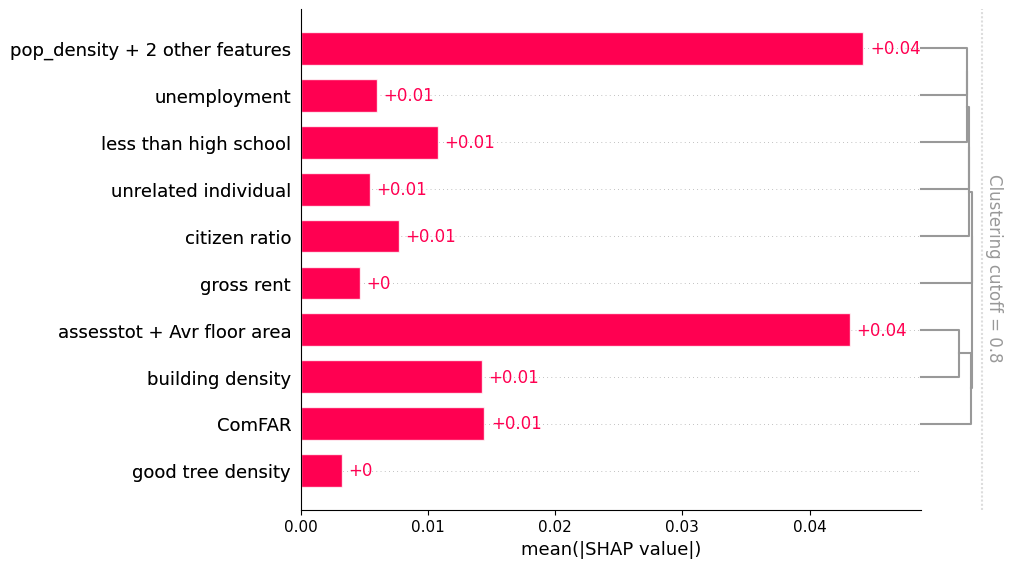

In [48]:
shap.plots.bar(shap_values_type[...,2], clustering=clustering1, clustering_cutoff=0.8)

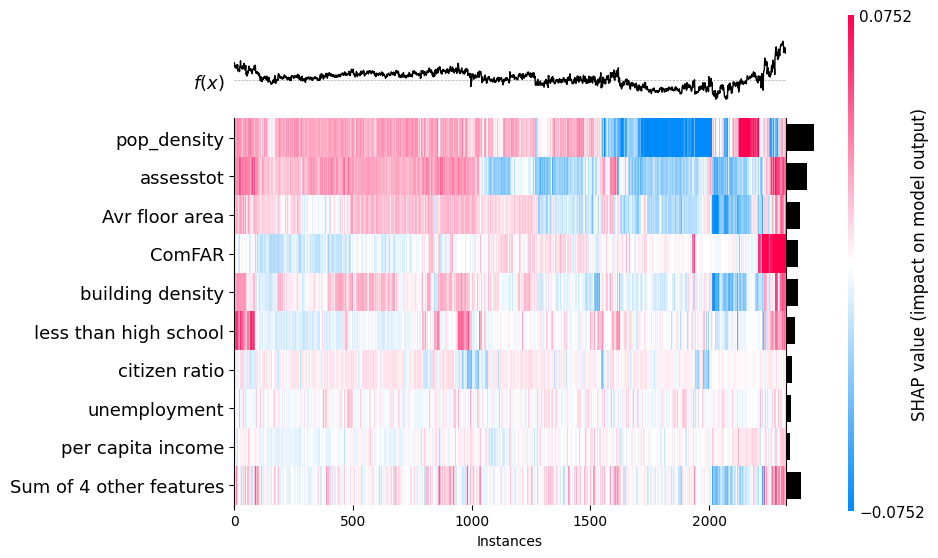

<Axes: xlabel='Instances'>

In [30]:
shap.plots.heatmap(shap_values_type[..., 2])

In [95]:
probs2=forest2.predict_proba(X_type)[...,2]

In [97]:
max_index_2=np.argmax(probs2)
min_index_2=np.argmin(probs2)
median_prob_2=np.median(probs2)
diff_2=np.abs(probs2-median_prob_2)
median_index_2=np.argmin(diff_2)
print(max_index_2)
print(min_index_2)
print(median_index_2)

2051
959
906


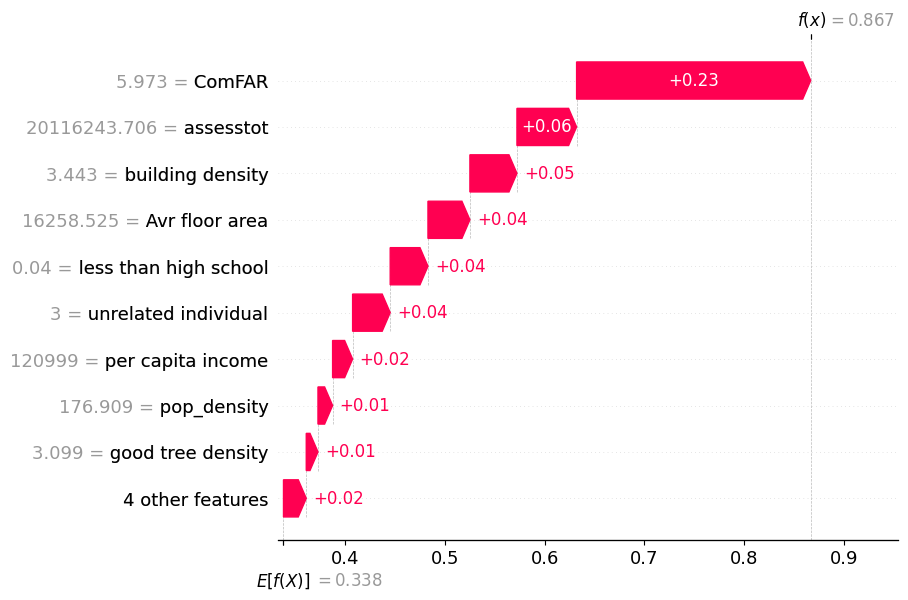

In [108]:
shap.plots.waterfall(shap_values_type[2051,..., 2])

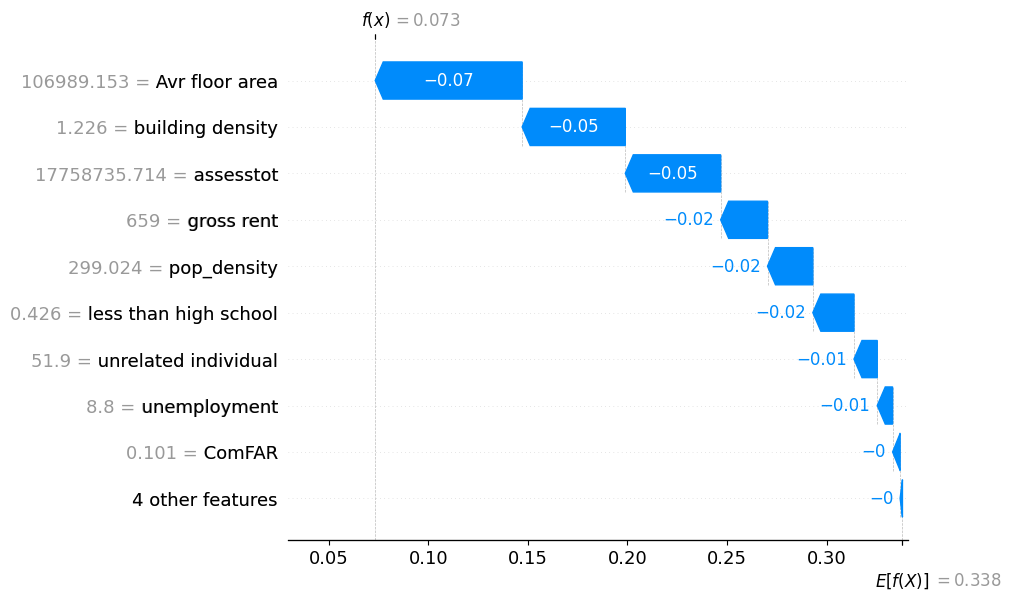

In [109]:
shap.plots.waterfall(shap_values_type[959,..., 2])

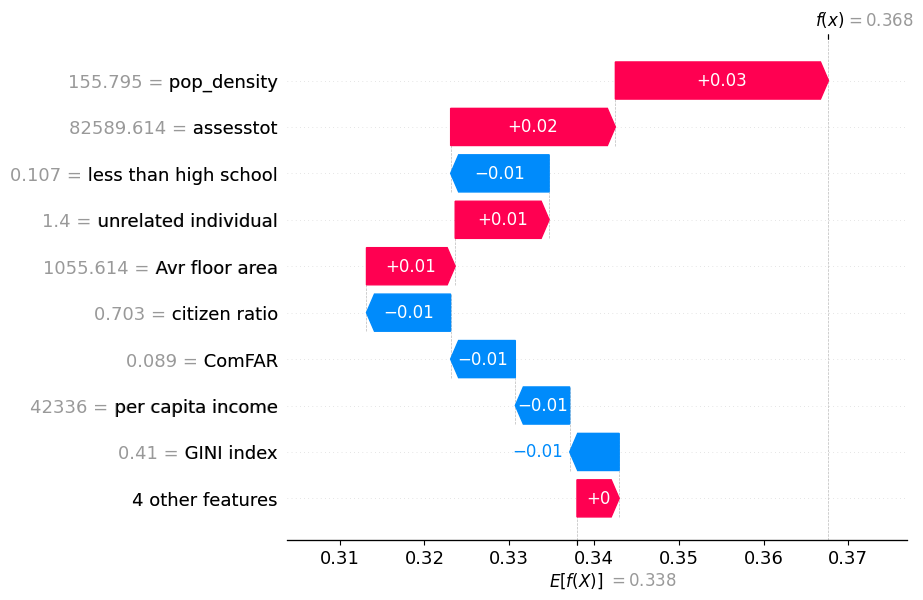

In [110]:
shap.plots.waterfall(shap_values_type[906,..., 2])

##### Classification: 0

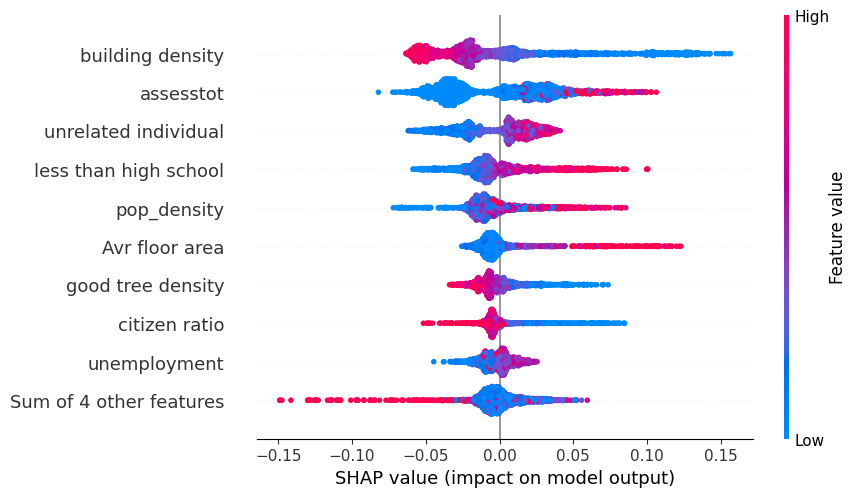

In [31]:
shap.plots.beeswarm(shap_values_type[..., 0])

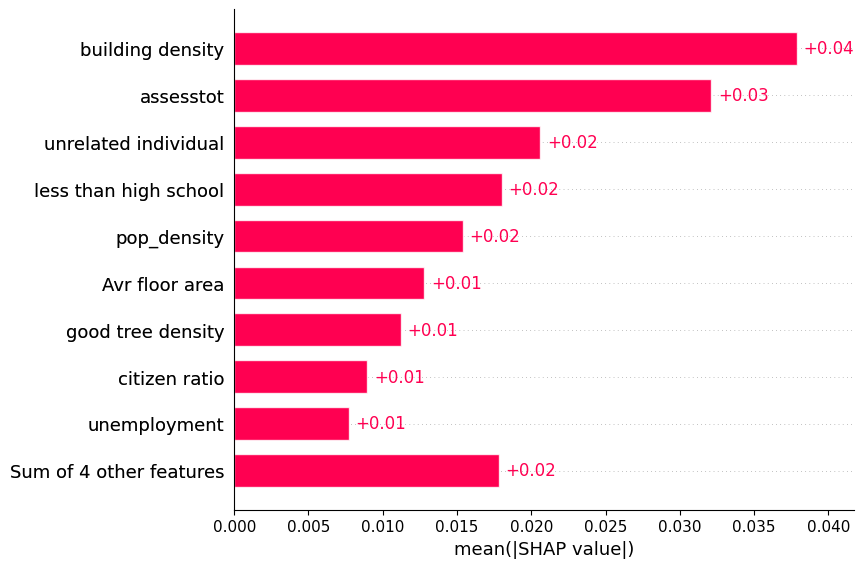

In [75]:
shap.plots.bar(shap_values_type[...,0])

In [35]:
y_type2=ct['pop_change_type_forest_prob_0']

In [45]:
clustering2 = shap.utils.hclust(X_type, y_type2)

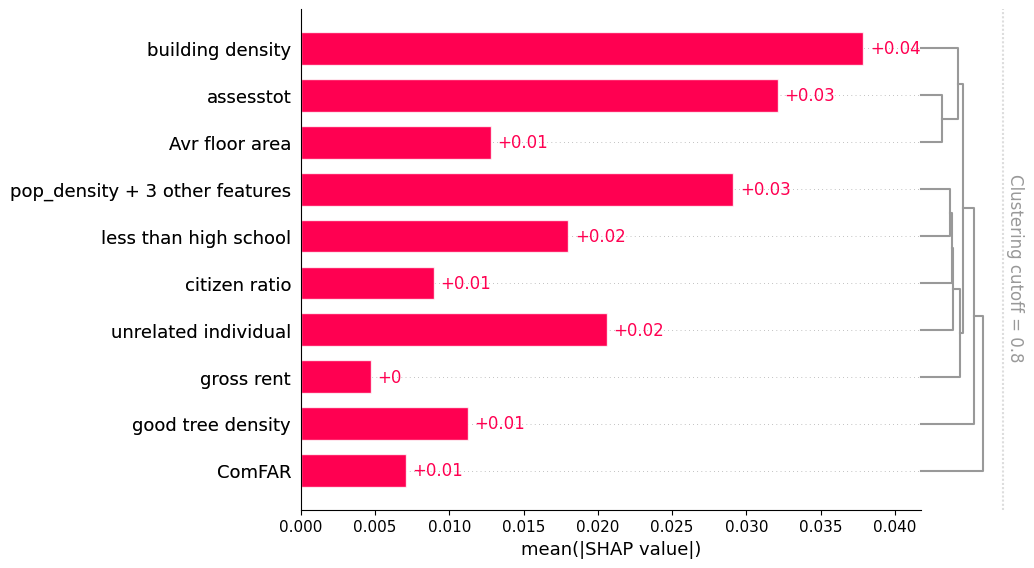

In [46]:
shap.plots.bar(shap_values_type[...,0], clustering=clustering2, clustering_cutoff=0.8)

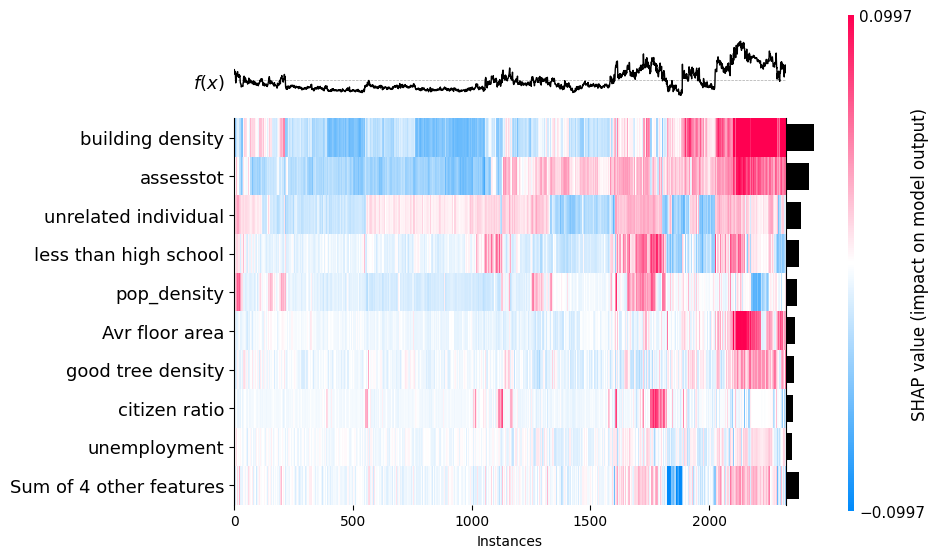

<Axes: xlabel='Instances'>

In [34]:
shap.plots.heatmap(shap_values_type[..., 0])

In [111]:
probs0=forest2.predict_proba(X_type)[...,0]

In [112]:
max_index_0=np.argmax(probs0)
min_index_0=np.argmin(probs0)
median_prob_0=np.median(probs0)
diff_0=np.abs(probs0-median_prob_0)
median_index_0=np.argmin(diff_0)
print(max_index_0)
print(min_index_0)
print(median_index_0)

1218
2166
1292


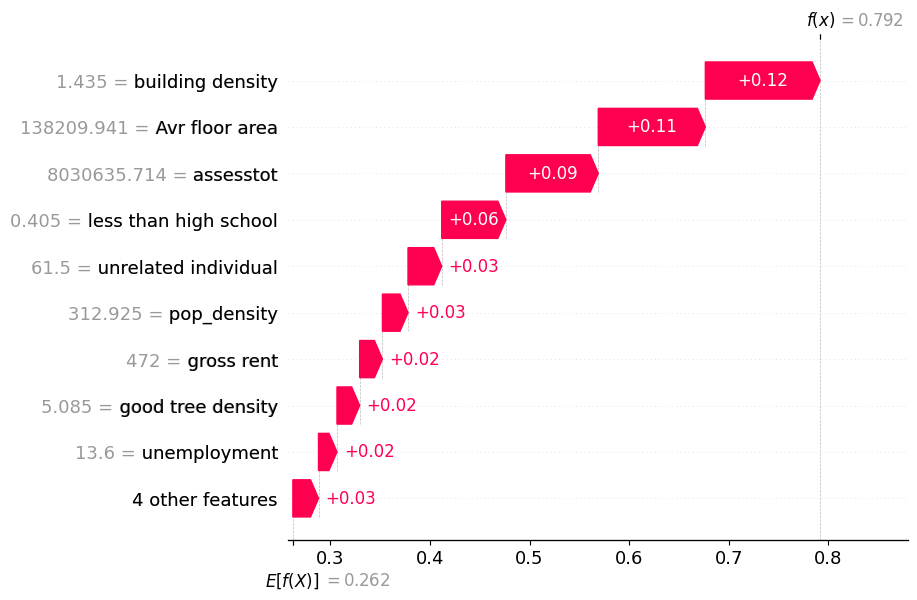

In [113]:
shap.plots.waterfall(shap_values_type[1218,...,0])

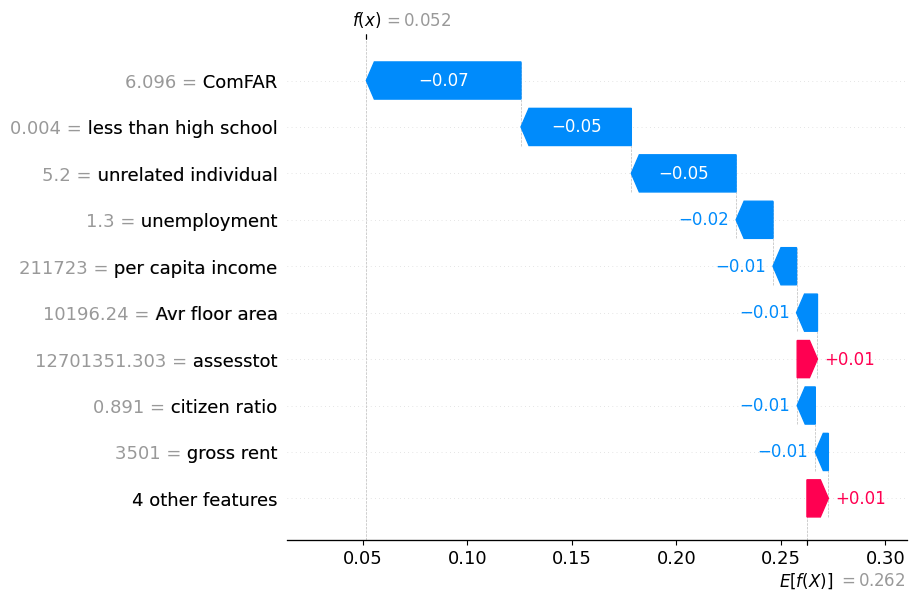

In [114]:
shap.plots.waterfall(shap_values_type[2166,...,0])

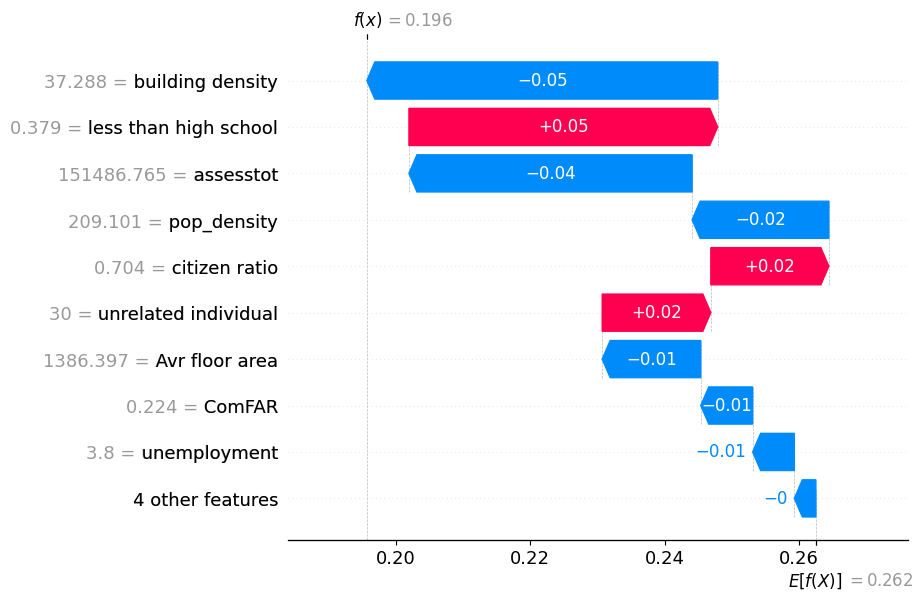

In [115]:
shap.plots.waterfall(shap_values_type[1292,...,0])